In [2]:
# Titanic Classification with Multiple ML Algorithms

# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# Step 1: Load the Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data = pd.read_csv(url)
print("First 5 rows of dataset:")
display(data.head())

# Step 2: Select features and target variable
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

X = data[features]
y = data[target]

# Step 3: Handle missing values
# 'Age' and 'Embarked' have missing values

# Impute numerical missing values with median
imputer_num = SimpleImputer(strategy='median')
X['Age'] = imputer_num.fit_transform(X[['Age']])

# Impute categorical missing values with most frequent value
# Impute categorical missing values with most frequent value
imputer_cat = SimpleImputer(strategy='most_frequent')
X['Embarked'] = imputer_cat.fit_transform(X[['Embarked']]).ravel()


# Step 4: Encode categorical features
X['Sex'] = LabelEncoder().fit_transform(X['Sex'])
X['Embarked'] = LabelEncoder().fit_transform(X['Embarked'])

# Step 5: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 6: Feature scaling (important for some algorithms)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Initialize machine learning models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Step 8: Train, predict and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}:")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


First 5 rows of dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Logistic Regression:
Accuracy: 0.8134
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       157
           1       0.80      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268


K-Nearest Neighbors:
Accuracy: 0.7873
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       157
           1       0.79      0.66      0.72       111

    accuracy                           0.79       268
   macro avg       0.79      0.77      0.77       268
weighted avg       0.79      0.79      0.78       268


Support Vector Machine:
Accuracy: 0.8209
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       157
           1       0.87      0.67      0.76       111

    accuracy                           0.82       268
   macro

C:\Users\User\AppData\Local\Temp\ipykernel_21028\2656040555.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Age'] = imputer_num.fit_transform(X[['Age']])
C:\Users\User\AppData\Local\Temp\ipykernel_21028\2656040555.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Embarked'] = imputer_cat.fit_transform(X[['Embarked']]).ravel()
C:\Users\User\AppData\Local\Temp\ipykernel_21028\2656040555.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .


Gradient Boosting:
Accuracy: 0.8060
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       157
           1       0.84      0.66      0.74       111

    accuracy                           0.81       268
   macro avg       0.81      0.78      0.79       268
weighted avg       0.81      0.81      0.80       268



Dataset shape: (891, 12)

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


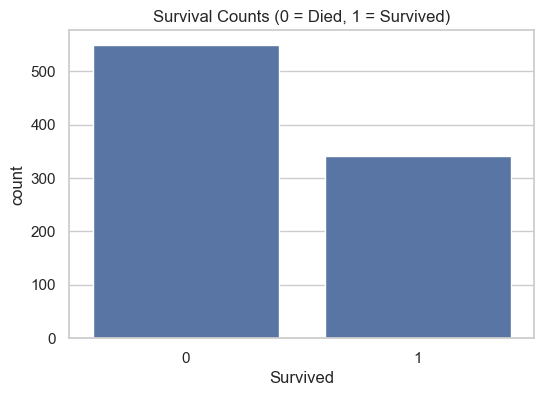

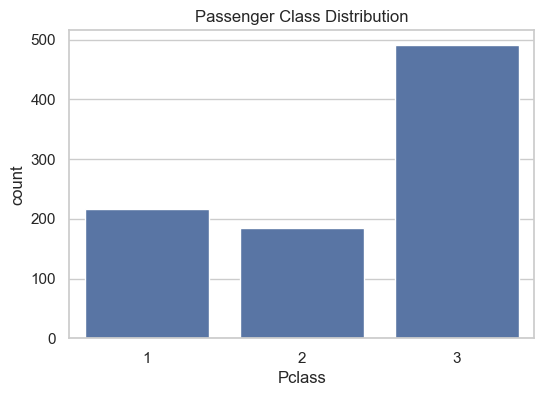

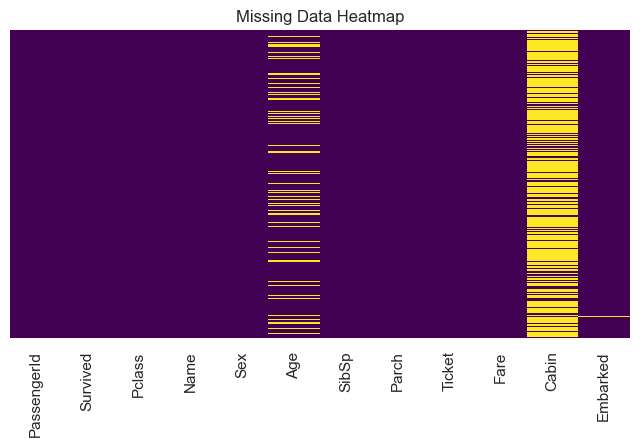

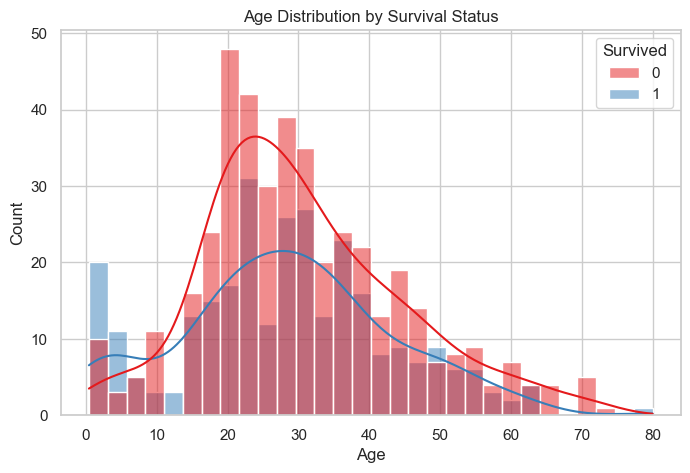

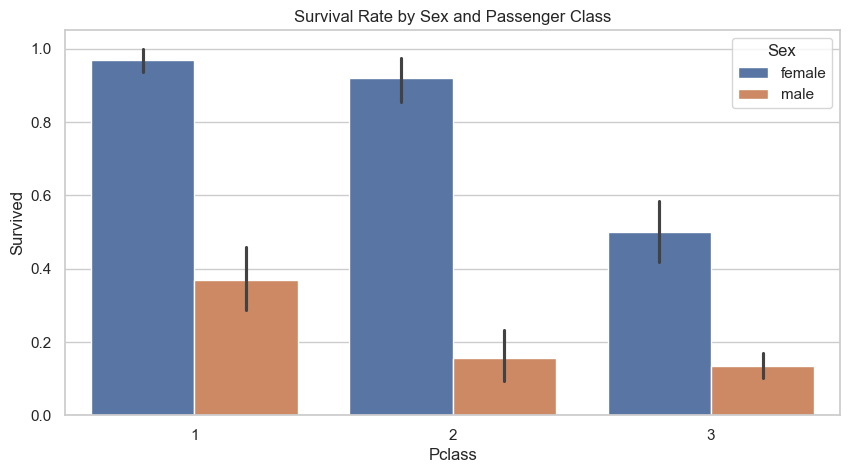


Logistic Regression Results:
Accuracy: 0.8134
              precision    recall  f1-score   support

        Died       0.82      0.87      0.85       157
    Survived       0.80      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



C:\Users\User\AppData\Local\Temp\ipykernel_21028\4042200597.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Age'] = imputer_num.fit_transform(X[['Age']])
C:\Users\User\AppData\Local\Temp\ipykernel_21028\4042200597.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Embarked'] = imputer_cat.fit_transform(X[['Embarked']]).ravel()
C:\Users\User\AppData\Local\Temp\ipykernel_21028\4042200597.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

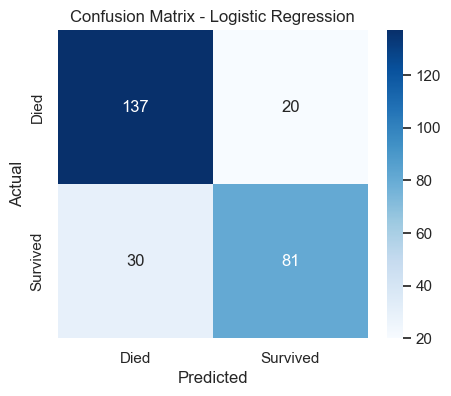


K-Nearest Neighbors Results:
Accuracy: 0.7873
              precision    recall  f1-score   support

        Died       0.78      0.88      0.83       157
    Survived       0.79      0.66      0.72       111

    accuracy                           0.79       268
   macro avg       0.79      0.77      0.77       268
weighted avg       0.79      0.79      0.78       268



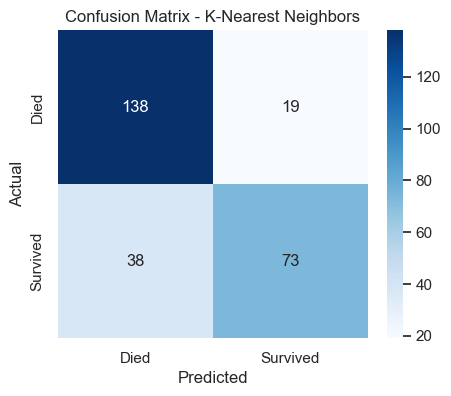


Support Vector Machine Results:
Accuracy: 0.8209
              precision    recall  f1-score   support

        Died       0.80      0.93      0.86       157
    Survived       0.87      0.67      0.76       111

    accuracy                           0.82       268
   macro avg       0.83      0.80      0.81       268
weighted avg       0.83      0.82      0.82       268



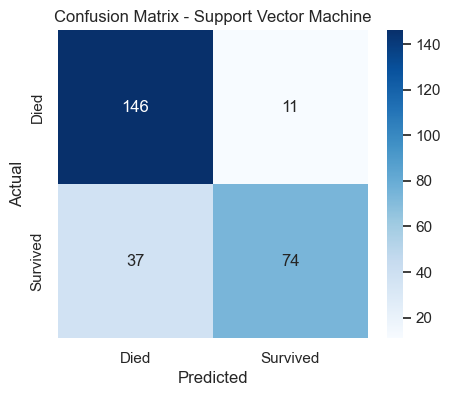


Decision Tree Results:
Accuracy: 0.7425
              precision    recall  f1-score   support

        Died       0.78      0.78      0.78       157
    Survived       0.69      0.68      0.69       111

    accuracy                           0.74       268
   macro avg       0.73      0.73      0.73       268
weighted avg       0.74      0.74      0.74       268



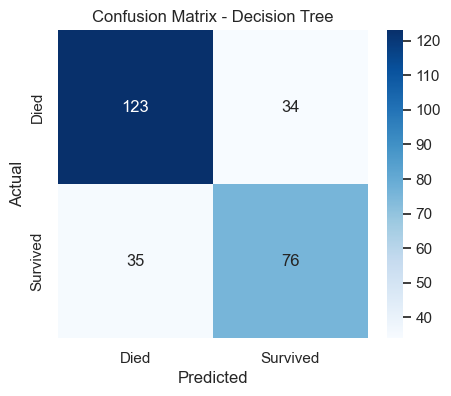


Random Forest Results:
Accuracy: 0.7612
              precision    recall  f1-score   support

        Died       0.79      0.81      0.80       157
    Survived       0.72      0.69      0.71       111

    accuracy                           0.76       268
   macro avg       0.75      0.75      0.75       268
weighted avg       0.76      0.76      0.76       268



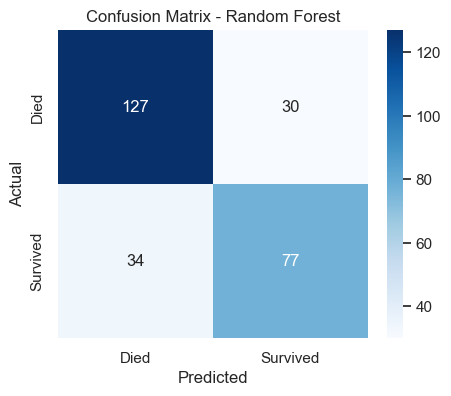


Naive Bayes Results:
Accuracy: 0.7985
              precision    recall  f1-score   support

        Died       0.84      0.82      0.83       157
    Survived       0.75      0.77      0.76       111

    accuracy                           0.80       268
   macro avg       0.79      0.80      0.79       268
weighted avg       0.80      0.80      0.80       268



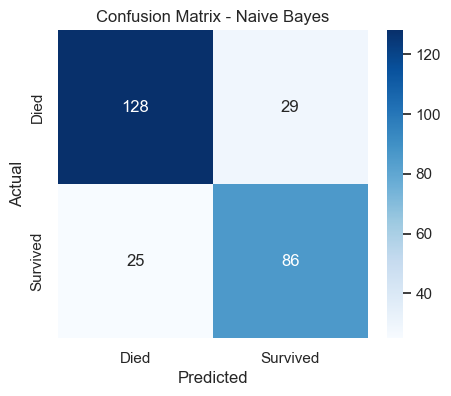


Gradient Boosting Results:
Accuracy: 0.8060
              precision    recall  f1-score   support

        Died       0.79      0.91      0.85       157
    Survived       0.84      0.66      0.74       111

    accuracy                           0.81       268
   macro avg       0.81      0.78      0.79       268
weighted avg       0.81      0.81      0.80       268



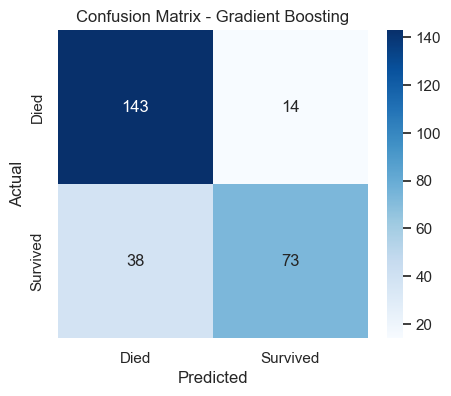

In [3]:
# Titanic Classification with Visualization and Multiple Models

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# Set seaborn style
sns.set(style="whitegrid")

# Step 1: Load data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data = pd.read_csv(url)

# Step 2: Initial Data Exploration
print(f"Dataset shape: {data.shape}")
print("\nMissing values per column:")
print(data.isnull().sum())

# Step 3: Visualizations

# Survival counts
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=data)
plt.title('Survival Counts (0 = Died, 1 = Survived)')
plt.show()

# Passenger Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=data)
plt.title('Passenger Class Distribution')
plt.show()

# Missing data heatmap
plt.figure(figsize=(8,4))
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# Age distribution by survival
plt.figure(figsize=(8,5))
sns.histplot(data=data, x='Age', hue='Survived', bins=30, kde=True, palette='Set1')
plt.title('Age Distribution by Survival Status')
plt.show()

# Survival rate by Sex and Pclass
plt.figure(figsize=(10,5))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=data)
plt.title('Survival Rate by Sex and Passenger Class')
plt.show()

# Step 4: Preprocessing

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

X = data[features]
y = data[target]

# Impute missing numerical values (Age)
imputer_num = SimpleImputer(strategy='median')
X['Age'] = imputer_num.fit_transform(X[['Age']])

# Impute missing categorical values (Embarked)
imputer_cat = SimpleImputer(strategy='most_frequent')
X['Embarked'] = imputer_cat.fit_transform(X[['Embarked']]).ravel()

# Encode categorical variables
X['Sex'] = LabelEncoder().fit_transform(X['Sex'])
X['Embarked'] = LabelEncoder().fit_transform(X['Embarked'])

# Step 5: Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 6: Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Helper function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Died', 'Survived'],
                yticklabels=['Died', 'Survived'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# Step 8: Train, predict and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{name} Results:")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))
    
    plot_confusion_matrix(y_test, y_pred, name)
